In [1]:
# Import the necessary libraries
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import json

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.data import AUTOTUNE
from tensorflow.keras import layers
import cv2

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the photos JSON file
photos_df = pd.read_json('./Yelp Photos/photos.json', lines=True)

In [3]:
# Check 10 samples
photos_df.sample(10)

,photo_id,business_id,caption,label
43307,pRewUn5LjPCmUgI89ouFaQ,YxgEEvmWQMDKqkDlof_TRA,,food
49181,kQrTc1u0-i1AMV_0ezSfcA,UcJbErL_KZbzKzxddiaIwQ,,inside
100038,lGdrGMJSA9YwYQ1AivrXXQ,WP9GAuhvmUhm8MAxMqhgrQ,,inside
85686,N3rw1Rms8W40Ua9eH9dm6w,9wu8pszrPPUjruNvgQtIEg,Mushroom soup,food
76965,HqsU44JQlZM358aZT0yQuQ,vXQLdqB-stL2JTP5AsPVaA,,food
14745,l3hTrRtaI9KPpBcFo4W7BQ,GfqPAxmkQQXFXAJ63aJUiA,Season kickoff champagne toast!,inside
95369,dKxmZ7H_0iUAny4zoe2RFQ,MEjSgFHOe8ed6D8Tt8JTvw,,inside
135217,lQSn5x7Div7p9BDNn48abA,oqVdjXJCEOkzLkmQvrBBPg,Affogato,food
40497,wNCEf8S0fH3x14hyFqmUSA,MJgHI9yuGej00bemw0R_uw,Great location,outside
198667,jA8_BF-M8qG-siu8AfEd-Q,5oX4G1cptixPZecih9L3dg,,food


In [4]:
# Check info
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


## Filter Valid Photos

In [5]:
# Remove all datasets with "Menu" label
photos_df = photos_df[photos_df['label'] != 'menu'].reset_index(drop=True)

In [6]:
# Image directory
img_dir = './Yelp Photos/photos'

In [7]:
def filter_valid_photos(df, image_dir):
    valid_indices = []
    for i, row in tqdm(df.iterrows(), total=len(df), desc="Validating photos"):
        photo_id = row['photo_id']
        img_path = os.path.join(image_dir, f'{photo_id}.jpg')
        try:
            _ = tf.keras.preprocessing.image.load_img(img_path)
            valid_indices.append(i)
        except Exception as e:
            continue
    return df.loc[valid_indices].reset_index(drop=True)

# Clean metadata
start_time = time.time()
photos_df = filter_valid_photos(photos_df, image_dir=img_dir)
print(f'After cleaning, metadata has {len(photos_df)} rows. Took {time.time()-start_time:.2f}s.')

Validating photos: 100%|██████████████████████████████████████████████████████| 198422/198422 [03:53<00:00, 848.24it/s]


After cleaning, metadata has 198316 rows. Took 234.05s.


In [8]:
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


# 4. cGAN

## Encode labels: [food, drink, inside, outside]

In [9]:
le = LabelEncoder()
photos_df['label_encoded'] = le.fit_transform(photos_df['label'])

encoder = OneHotEncoder(sparse_output=False)
onehot_labels = encoder.fit_transform(photos_df[['label_encoded']])

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Test small sample
sample_df = photos_df.sample(5)
print(sample_df[['photo_id', 'label', 'label_encoded']])

Label mapping: {'drink': 0, 'food': 1, 'inside': 2, 'outside': 3}
                      photo_id    label  label_encoded
189836  i2nkEDrg6dweIxzzyKOW5w     food              1
105978  ISb3p-stxPBO05PTILyqHg  outside              3
161339  iQl7LBF9NXSVRbI34T7rBw   inside              2
40313   uEyvJLbZ5sz1EBXuCqCozA   inside              2
6682    wrxaxPAEjMJau8aDDqbUPw     food              1


## Load sample images to test pipeline

In [10]:
def load_images(photo_ids, directory=img_dir, target_size=(64,64)):
    images = []
    for pid in tqdm(photo_ids, desc="Loading images"):
        try:
            path = os.path.join(directory, f'{pid}.jpg')
            img = tf.keras.preprocessing.image.load_img(path, target_size=target_size)
            img = tf.keras.preprocessing.image.img_to_array(img) / 255.0
            images.append(img)
        except Exception as e:
            print(f'Could not load {path}: {e}')
            continue
    return np.array(images)

# Load a small sample for quick test
start_time = time.time()
test_sample = load_images(photos_df['photo_id'].sample(5))
print(f'Loaded {len(test_sample)} sample images in {time.time()-start_time:.2f}s')

Loading images: 100%|████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 90.96it/s]

Loaded 5 sample images in 0.07s


## Load 20,000 sample images from the main dataframe

In [11]:
# Sample 4,000 from each label
sample_size = 80

photos_df = pd.concat([
    photos_df[photos_df['label'] == l].sample(sample_size, replace=True) 
    for l in ['food', 'drink', 'inside', 'outside']
]).sample(frac=1).reset_index(drop=True)

In [12]:
# Print photos_df
print(photos_df.head())

                 photo_id             business_id                caption  \
0  P4KIXmKjN3ZKRiNVZ4SRUw  2PeuTPjcC5jEyrMt9o-w7w  Rum Baba with filling   
1  VScdPP6RXezITgaTDTpEpg  HC_F1uM-1CK2TVfpnU7-TQ    Dining area inside.   
2  PKgEBNqKjx-Zqw4ULVdGgw  OaddVySRpJcU9LNa8bkGMw                          
3  VNI7uEAJSxEe2npYjueVXw  hc7I_QpCszT3mlIP9uW19w                          
4  Zqggk88PyZQUCIOOgMGgEA  AbnrloAMqhmAvjdQkEbPkQ      Sunset from table   

     label  label_encoded  
0     food              1  
1   inside              2  
2   inside              2  
3   inside              2  
4  outside              3  


In [13]:
start_time = time.time()
images_df = load_images(photos_df['photo_id'])
print(f'Loaded {len(images_df)} total images in {time.time()-start_time:.2f}s')

Loading images: 100%|███████████████████████████████████████████████████████████████| 320/320 [00:03<00:00, 103.27it/s]

Loaded 320 total images in 3.11s


In [14]:
# Create arrays and specify labels
valid_indices = [i for i, img in enumerate(images_df)]
all_images = np.array(images_df)
all_labels = onehot_labels[photos_df['label_encoded']]

print('Final dataset shape:', all_images.shape, all_labels.shape)

Final dataset shape: (320, 64, 64, 3) (320, 4)


# Build cGAN

## Generator

In [15]:
def make_generator():
    noise_input = layers.Input(shape=(100,))
    label_input = layers.Input(shape=(4,))
    x = layers.Concatenate()([noise_input, label_input])
    x = layers.Dense(8*8*256)(x)
    x = layers.Reshape((8,8,256))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (4,4), strides=(2,2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(3, (4,4), strides=(2,2), padding='same', activation='tanh')(x)
    return tf.keras.Model([noise_input, label_input], x, name='Generator')

generator = make_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 104)               │               0 │ input_layer[0][0],         │
│                               │                           │                 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 16384)             │       1,720,320 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 8, 8, 256)         │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 8, 8, 256)         │           1,024 │ reshape[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu (LeakyReLU)       │ (None, 8, 8, 256)         │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose              │ (None, 16, 16, 128)       │         524,416 │ leaky_re_lu[0][0]          │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 16, 16, 128)       │             512 │ conv2d_transpose[0][0]     │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU)     │ (None, 16, 16, 128)       │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_1            │ (None, 32, 32, 64)        │         131,136 │ leaky_re_lu_1[0][0]        │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 32, 32, 64)        │             256 │ conv2d_transpose_1[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU)     │ (None, 32, 32, 64)        │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_2            │ (None, 64, 64, 3)         │           3,075 │ leaky_re_lu_2[0][0]        │
│ (Conv2DTranspose)             │                           │               

 Total params: 2,380,739 (9.08 MB)

 Trainable params: 2,379,843 (9.08 MB)

 Non-trainable params: 896 (3.50 KB)

## Discriminator

In [16]:
def make_discriminator():
    img_input = layers.Input(shape=(64,64,3))
    label_input = layers.Input(shape=(4,))
    label_img = layers.Dense(64*64*1)(label_input)
    label_img = layers.Reshape((64,64,1))(label_img)

    x = layers.Concatenate()([img_input, label_img])
    x = layers.Conv2D(64, (4,4), strides=(2,2), padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (4,4), strides=(2,2), padding='same')(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1)(x)
    return tf.keras.Model([img_input, label_input], x, name='Discriminator')

discriminator = make_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 4096)              │          20,480 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 64, 64, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_1 (Reshape)           │ (None, 64, 64, 1)         │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 64, 64, 4)         │               0 │ input_layer_2[0][0],       │
│                               │                           │                 │ reshape_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 32, 32, 64)        │           4,160 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU)     │ (None, 32, 32, 64)        │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 32, 32, 64)        │               0 │ leaky_re_lu_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 16, 16, 128)       │         131,200 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_4 (LeakyReLU)     │ (None, 16, 16, 128)       │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 16, 16, 128)       │               0 │ leaky_re_lu_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 32768)             │               0 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 1)                 │          32,769 │ flatten[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 188,609 (736.75 KB)

 Trainable params: 188,609 (736.75 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [17]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
gen_opt = tf.keras.optimizers.Adam(1e-4)
disc_opt = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images, labels):
    noise = tf.random.normal([images.shape[0], 100])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, labels], training=True)
        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
        disc_loss = (cross_entropy(tf.ones_like(real_output), real_output)
                     + cross_entropy(tf.zeros_like(fake_output), fake_output))

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_opt.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    disc_opt.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    return gen_loss, disc_loss

## Training loop

In [25]:
# Sample generator function
def generate_sample(label_text, ax):
    idx = le.transform([label_text])
    onehot = encoder.transform(idx.reshape(-1,1))
    onehot = tf.convert_to_tensor(onehot, dtype=tf.float32)
    noise = tf.random.normal([1,100])
    gen_img = generator([noise, onehot], training=False)
    ax.imshow((gen_img[0]+1)/2)
    ax.set_title(label_text)
    ax.axis('off')

Epoch 1: 100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.48s/it]


Epoch 1: Gen loss=0.9924, Disc loss=1.3563 in 7.38s


Epoch 2: 100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:10<00:00,  2.17s/it]


Epoch 2: Gen loss=1.0497, Disc loss=1.2143 in 10.83s


Epoch 3: 100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:08<00:00,  1.65s/it]


Epoch 3: Gen loss=0.5908, Disc loss=1.4849 in 8.27s


Epoch 4: 100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:06<00:00,  1.25s/it]


Epoch 4: Gen loss=1.0466, Disc loss=1.4571 in 6.27s


Epoch 5: 100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:06<00:00,  1.30s/it]


Epoch 5: Gen loss=0.8334, Disc loss=1.3513 in 6.49s
Showing generated samples at epoch 5


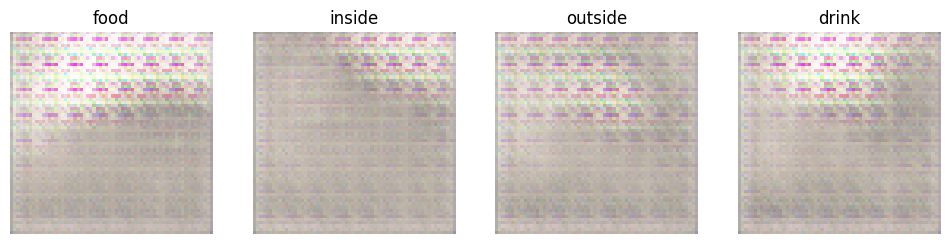

Epoch 6: 100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:06<00:00,  1.38s/it]


Epoch 6: Gen loss=0.7104, Disc loss=1.3770 in 6.91s


Epoch 7: 100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.51s/it]


Epoch 7: Gen loss=0.8768, Disc loss=1.7513 in 7.57s


Epoch 8: 100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:08<00:00,  1.77s/it]


Epoch 8: Gen loss=0.8503, Disc loss=1.5978 in 8.85s


Epoch 9: 100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:08<00:00,  1.66s/it]


Epoch 9: Gen loss=0.8336, Disc loss=1.5945 in 8.30s


Epoch 10: 100%|██████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.58s/it]


Epoch 10: Gen loss=1.0440, Disc loss=1.4492 in 7.93s
Showing generated samples at epoch 10


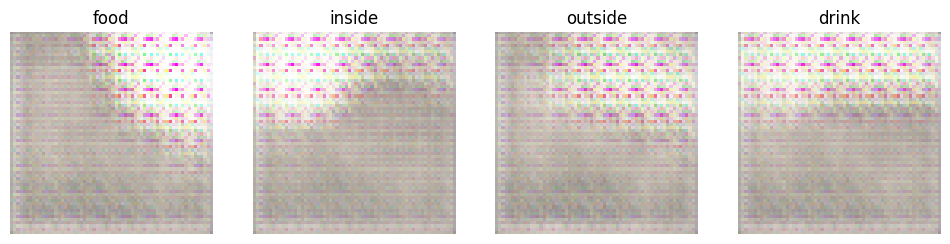

In [27]:
# Training loop
AUTOTUNE = tf.data.AUTOTUNE

dataset = tf.data.Dataset.from_tensor_slices((all_images, all_labels)).shuffle(1000).batch(64).prefetch(AUTOTUNE)

for epoch in range(1000):
    start_epoch = time.time()
    for batch_images, batch_labels in tqdm(dataset, desc=f"Epoch {epoch+1}"):
        g_loss, d_loss = train_step(batch_images, batch_labels)

    print(f'Epoch {epoch+1}: Gen loss={g_loss.numpy():.4f}, Disc loss={d_loss.numpy():.4f} '
          f'in {time.time()-start_epoch:.2f}s')

    if (epoch+1) % 100 == 0:
        print(f'Showing generated samples at epoch {epoch+1}')
        fig, axes = plt.subplots(1, 4, figsize=(12,3))
        generate_sample('food', axes[0])
        generate_sample('inside', axes[1])
        generate_sample('outside', axes[2])
        generate_sample('drink', axes[3])
        plt.show()

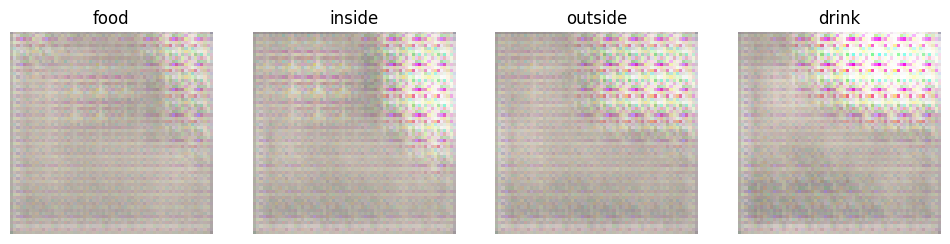

In [32]:
# Plot Sample of generated images
fig, axes = plt.subplots(1, 4, figsize=(12,3))
generate_sample('food', axes[0])
generate_sample('inside', axes[1])
generate_sample('outside', axes[2])
generate_sample('drink', axes[3])
plt.show()

## Evaluation of cGAN

In [28]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from scipy.linalg import sqrtm

def compute_inception_and_fid(real_imgs, fake_imgs):
    # resize to (299,299,3) for InceptionV3
    real_imgs_resized = tf.image.resize(real_imgs, (299, 299)).numpy()
    fake_imgs_resized = tf.image.resize(fake_imgs, (299, 299)).numpy()

    # preprocess
    real_imgs_resized = preprocess_input(real_imgs_resized)
    fake_imgs_resized = preprocess_input(fake_imgs_resized)

    # get features
    model = InceptionV3(include_top=False, pooling='avg', input_shape=(299,299,3))
    act_real = model.predict(real_imgs_resized, verbose=0)
    act_fake = model.predict(fake_imgs_resized, verbose=0)

    # calculate means and covariances
    mu1, sigma1 = act_real.mean(axis=0), np.cov(act_real, rowvar=False)
    mu2, sigma2 = act_fake.mean(axis=0), np.cov(act_fake, rowvar=False)

    # calculate FID
    ssdiff = np.sum((mu1 - mu2)**2)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2*covmean)

    print("FID Score:", fid)
    is_score = np.exp(np.mean(np.log(1e-6 + np.var(act_fake, axis=0))))
    print("Inception Score:", is_score)

In [29]:
# Plot distribution
def plot_latent_distributions(real_imgs, fake_imgs, real_labels, fake_labels, discriminator):
    real_preds = discriminator([real_imgs, real_labels], training=False).numpy().flatten()
    fake_preds = discriminator([fake_imgs, fake_labels], training=False).numpy().flatten()

    plt.figure(figsize=(8,5))
    plt.hist(real_preds, bins=30, alpha=0.6, label="Real", color='g')
    plt.hist(fake_preds, bins=30, alpha=0.6, label="Fake", color='r')
    plt.legend()
    plt.title("Discriminator Score Distributions")
    plt.xlabel("Score")
    plt.ylabel("Frequency")
    plt.show()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step
FID Score: 3.8691697314244022
Inception Score: 1.52175035e-05


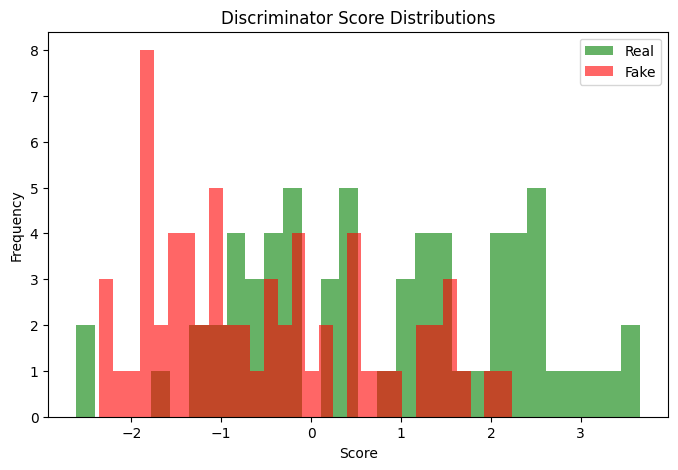

In [30]:
# Suppose you have batches
real_imgs, real_labels = next(iter(dataset))
noise = tf.random.normal([len(real_imgs), 100])
fake_imgs = generator([noise, real_labels], training=False)

# Compute metrics
compute_inception_and_fid(real_imgs, fake_imgs)

# Plot discriminator separation
plot_latent_distributions(real_imgs, fake_imgs, real_labels, real_labels, discriminator)